# Dataset & LIbraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers, Sequential

import matplotlib.pyplot as plt
import numpy as np
#from sklearn.utils import 
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
source_dir = "/kaggle/input/datasets/geadalfa/cracked-non-cracked-surface-datasets/Bangunan Retak"
dest_dir = "/kaggle/working/NewDataset"

Splitting into separate Train, Val & Test folders

In [ ]:
import splitfolders
splitfolders.ratio(source_dir, output=dest_dir, ratio=(.8, .15, .05), group_prefix=None, move=False)

# Preprocessing

Image Dataset Preprocessing and Loading

In [10]:
batch_size = 64
image_size = (224, 224)

train = keras.preprocessing.image_dataset_from_directory(dest_dir + '/train', label_mode = "categorical", batch_size = batch_size, image_size = image_size, )
val = keras.preprocessing.image_dataset_from_directory(dest_dir + '/val', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )
test = keras.preprocessing.image_dataset_from_directory(dest_dir + '/test', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )

Found 76873 files belonging to 2 classes.
Found 14413 files belonging to 2 classes.
Found 4806 files belonging to 2 classes.


Performance Optimization: Prefetch

In [11]:
train_copy = train
test_copy = test
train = train.prefetch(buffer_size=tf.data.AUTOTUNE)
val = val.prefetch(buffer_size=tf.data.AUTOTUNE)
test = test.prefetch(buffer_size=tf.data.AUTOTUNE)

Class Weight Computation for Imbalanced Datasets

In [8]:
import os
import numpy as np
from sklearn.utils import class_weight

# 1. Define the path to your training folder 
# (This should match what you used in image_dataset_from_directory)
train_dir = dest_dir + '/train'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(train_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_train_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_train_simulated.extend([i] * num_images)

y_train_simulated = np.array(y_train_simulated)

# 4. Compute the class weights using sklearn
class_labels = np.unique(y_train_simulated)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train_simulated
)

# 5. Format into the dictionary Keras expects
class_weights = dict(zip(class_labels, class_weights_array))

# Display the results
class_indices = {class_names[i]: i for i in range(len(class_names))}
print(f"Class indices: {class_indices}")
print(f"Calculated weights: {class_weights}")

Class indices: {'Cracked': 0, 'Non Cracked': 1}
Calculated weights: {np.int64(0): np.float64(1.6867731601351648), np.int64(1): np.float64(0.7106552527456274)}


# Hyperparameter optimization

In [9]:
!pip install optuna
!pip install optuna-integration[tfkeras]

Hyperparameter Optimization and Dynamic CNN Architecture Tuning with Optuna

In [ ]:
import optuna
from optuna.integration import TFKerasPruningCallback

# Take 200 batches (6,400 images) for training and 50 batches (1,600 images) for validation.
tune_train = train.take(200)

def objective(trial):
    # 1. Clear session to avoid cluttering memory
    tf.keras.backend.clear_session()
    
    # --- 2. Suggest Hyperparameters ---
    # Architectural parameters
    n_blocks = trial.suggest_int("n_blocks", 3, 6)
    base_filters = trial.suggest_categorical("base_filters", [32, 64])
    dense_units = trial.suggest_int("dense_units", 128, 512, step=128)
    
    # Regularization & Learning Rate
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    # 1e-2 is usually too aggressive for deep CNNs with Adam, capped at 1e-3
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    # --- 3. Build VGG-Style Model Dynamically ---
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(224, 224, 3)))
    
    # Dynamically stack 3 to 5 VGG blocks
    for i in range(n_blocks):
        # Double the filters each block (e.g., 32 -> 64 -> 128 -> 256)
        # Capped at 512 to prevent parameter explosion in deeper blocks
        filters = min(base_filters * (2 ** i), 512)
        
        model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same", use_bias=False))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
        model.add(layers.MaxPooling2D())
        
    
    # Use GlobalAveragePooling2D instead of Flatten. 
    # Flattening a 224x224 image after only 3 blocks creates a massive Dense layer
    # that can instantly exhaust GPU memory. Global pooling avoids this bottleneck.
    model.add(layers.GlobalAveragePooling2D())

    # Classification Head
    model.add(layers.Dense(dense_units, use_bias=False, kernel_regularizer=regularizers.l2(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(2, activation="softmax"))

    # --- 4. Compile Model ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # --- 5. Callbacks & Training ---
    callbacks = [
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
    ]
    
    history = model.fit(
        tune_train, # Your existing generator
        validation_data=val,
        epochs=15,       # Set a reasonable max
        callbacks=callbacks,
        class_weight=class_weights,
    )
    
    # Return max val_accuracy (better than [-1] because of Early Stopping)
    return max(history.history["val_accuracy"])

# Run the study
# Added MedianPruner to aggressively stop bad trials early
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

# CNNs take longer to train; 20 trials is a solid sweet spot for this search space
study.optimize(objective, n_trials=20) 

print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

[I 2026-04-30 23:19:28,386] A new study created in memory with name: no-name-1d5c2c2e-797f-4048-bece-0195abd20ae8


Epoch 1/15


I0000 00:00:1777591172.984856    2534 service.cc:152] XLA service 0x783394209370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777591172.985996    2534 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777591172.986196    2534 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777591173.860812    2534 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/200 ━━━━━━━━━━━━━━━━━━━━ 57:31 17s/step - accuracy: 0.7656 - loss: 0.6227

I0000 00:00:1777591186.762509    2534 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8263 - loss: 0.4861

[I 2026-05-01 01:12:41,285] Trial 18 pruned. Trial was pruned at epoch 0.


Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8325 - loss: 0.4671

[I 2026-05-01 01:14:14,436] Trial 19 pruned. Trial was pruned at epoch 0.


Best trial: 0.9320058226585388
Best params: {'n_blocks': 6, 'base_filters': 64, 'dense_units': 128, 'dropout_rate': 0.2540226461946239, 'lr': 0.0005165001341158376}


In [11]:
print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

Best trial: 0.9320058226585388
Best params: {'n_blocks': 6, 'base_filters': 64, 'dense_units': 128, 'dropout_rate': 0.2540226461946239, 'lr': 0.0005165001341158376}


# Training

Reconstructing and Training the Final Model with Optimal Hyperparameters

In [ ]:
# --- 1. Parse the Best Parameters Automatically ---
# study.best_params is a dictionary containing the winning values
best_params = study.best_params

print("Training final model with parameters:", best_params)

# --- 2. Re-instantiate Data Augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

# --- 3. Build Final Model Dynamically using Parsed Variables ---
model = tf.keras.Sequential()
model.add(layers.Input(shape=(224, 224, 3)))
model.add(data_augmentation)

# Build blocks using the parsed 'n_blocks' and 'base_filters'
for i in range(best_params['n_blocks']):
    filters = min(best_params['base_filters'] * (2 ** i), 512)
    
    model.add(layers.Conv2D(filters, (3, 3), activation="relu", padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

model.add(layers.GlobalAveragePooling2D())

# Classification Head using parsed 'dense_units' and 'dropout_rate'
model.add(layers.Dense(best_params['dense_units'], use_bias=False, kernel_regularizer=regularizers.l2(1e-5)))
model.add(layers.BatchNormalization())
model.add(layers.ReLU())
model.add(layers.Dropout(best_params['dropout_rate']))
model.add(layers.Dense(2, activation="softmax"))

# --- 4. Compile using the parsed 'lr' ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Final Callbacks ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_crack_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1, mode="min")
]

# --- 6. Train on the FULL Dataset ---
# Notice we are using 'train' and 'val' here, NOT 'tune_train' or 'tune_val'
history = model.fit(
    train,               
    validation_data=val,
    epochs=100,           
    callbacks=callbacks,
    class_weight=class_weights
)

Training final model with parameters: {'n_blocks': 6, 'base_filters': 64, 'dense_units': 128, 'dropout_rate': 0.2540226461946239, 'lr': 0.0005165001341158376}
Epoch 1/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 713s 589ms/step - accuracy: 0.8711 - loss: 0.3476 - val_accuracy: 0.8331 - val_loss: 0.4095 - learning_rate: 5.1650e-04
Epoch 2/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 706s 587ms/step - accuracy: 0.9199 - loss: 0.2501 - val_accuracy: 0.9148 - val_loss: 0.2490 - learning_rate: 5.1650e-04
Epoch 3/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 703s 585ms/step - accuracy: 0.9280 - loss: 0.2312 - val_accuracy: 0.9150 - val_loss: 0.2514 - learning_rate: 5.1650e-04
Epoch 4/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9302 - loss: 0.2250
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00025825007469393313.
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 702s 584ms/step - accuracy: 0.9302 - loss: 0.2250 - val_accuracy: 0.8643 - val_loss: 0.4694 - learning_rate: 5.1650e-04
Epoch 5/100
1202/1202 ━━━━━━━━━━━

# Evaluation & Visualization

Model Performance Evaluation on Test Dataset

In [15]:
#loss, accuracy, precision, recall
print(model.evaluate(test))

76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.9554 - loss: 0.1098
[0.12720488011837006, 0.9579691886901855]


Visualizing Training History: Loss and Accuracy Curves

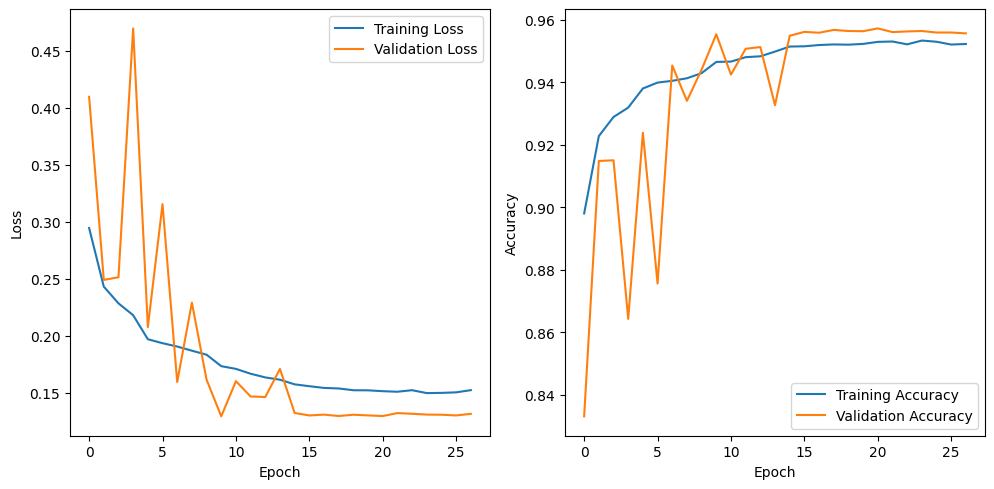

In [17]:
plt.figure(figsize=(15, 5))

# --- Loss ---
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Accuracy ---
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Confusion Matrix Visualization and Error Analysis

In [18]:
test_dir = dest_dir + '/test'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(test_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_test_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_test_simulated.extend([i] * num_images)

y_true = np.array(y_test_simulated)



# Use the model to predict the classes
y_pred = np.argmax(model.predict(test), axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step


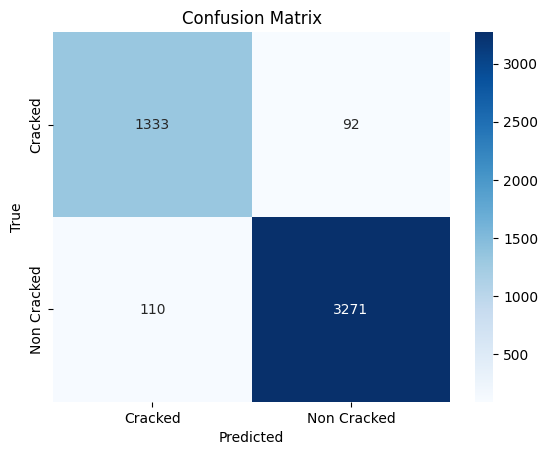

[[1333   92]
 [ 110 3271]]


In [19]:
import seaborn as sns

# Compute and print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_copy.class_names, yticklabels=test_copy.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(conf_matrix)

Loading saved model

In [4]:
Model = keras.models.load_model("best_cnn_model.keras")
Model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 128)  │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 512)    │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,296 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 19,020,104 (72.56 MB)

 Trainable params: 6,338,626 (24.18 MB)

 Non-trainable params: 4,224 (16.50 KB)

 Optimizer params: 12,677,254 (48.36 MB)